In [27]:
import pysam
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import warnings
import math
from sklearn.preprocessing import LabelEncoder


In [2]:
def is_empty_vcf(vcf_file):
    vcf = pysam.VariantFile(vcf_file)
    for _ in vcf:
        return False
    return True

In [5]:
vcf_dir = "annotated_vcf_files"
vcf_files = sorted(os.listdir(vcf_dir))
vcf_files = [vcf_file for vcf_file in vcf_files if vcf_file.endswith(".vcf")]
vcf_files = [os.path.join(vcf_dir, vcf_file) for vcf_file in vcf_files]
vcf_files = [vcf_file for vcf_file in vcf_files if not is_empty_vcf(vcf_file)]
sample_file = pysam.VariantFile(vcf_files[0])

In [6]:
fields = set(sample_file.header.info.keys())
print(f"Fileds: {fields}")

Fileds: {'BaseQRankSum', 'InbreedingCoeff', 'CSQ', 'ReadPosRankSum', 'HaplotypeScore', 'FS', 'QD', 'DP', 'EXON', 'AC', 'HRun', 'SB', 'AN', 'MQ', 'TI', 'GI', 'AF', 'Dels', 'MQRankSum', 'FC', 'DS', 'MQ0'}


In [7]:
csq_fields = {}
for tag in fields:
	desc = sample_file.header.info[tag].description
	
	if tag == "CSQ":
		desc = desc.split(":")[1]
		desc = desc.split("|")
		for i in range(len(desc) - 1):
			field = desc[i]
			csq_fields[field] = i

In [8]:
print(csq_fields.keys())

dict_keys([' Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Gene', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'HGVSc', 'HGVSp', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'DISTANCE', 'STRAND', 'FLAGS', 'SYMBOL_SOURCE', 'HGNC_ID', 'CANONICAL', '1000Gp3_AC', '1000Gp3_AF', '1000Gp3_AFR_AC', '1000Gp3_AFR_AF', '1000Gp3_AMR_AC', '1000Gp3_AMR_AF', '1000Gp3_EAS_AC', '1000Gp3_EAS_AF', '1000Gp3_EUR_AC', '1000Gp3_EUR_AF', '1000Gp3_SAS_AC', '1000Gp3_SAS_AF', 'ALFA_African_AC', 'ALFA_African_AF', 'ALFA_African_AN', 'ALFA_African_American_AC', 'ALFA_African_American_AF', 'ALFA_African_American_AN', 'ALFA_African_Others_AC', 'ALFA_African_Others_AF', 'ALFA_African_Others_AN', 'ALFA_Asian_AC', 'ALFA_Asian_AF', 'ALFA_Asian_AN', 'ALFA_East_Asian_AC', 'ALFA_East_Asian_AF', 'ALFA_East_Asian_AN', 'ALFA_European_AC', 'ALFA_European_AF', 'ALFA_European_AN', 'ALFA_Latin_American_1_AC', 'ALFA_Latin_American_1_AF', 'ALFA_Latin_American_1_AN', '

In [24]:

feature_names = [
"id",
"label",
"Variant_position",
"Variant_length",
"Consequence",
# "HGVS",
# "HGVSc",
# "HGVSc_VEP",
# "HGVSc_ANNOVAR",
# "HGVSc_snpEff",
# "clinvar_hgvs",
"Exon_number",
"Intron_number",
'cDNA_position', 
'CDS_position', 
'Protein_position', 
'Amino_acids', 
'Codons', 
'SiPhy_29way_logOdds', 
'aaalt', 
# 'aapos', 
'aaref', 
'alt', 
'bStatistic', 
'codon_degeneracy', 
'codonpos', 
'phastCons100way_vertebrate', 
'phastCons17way_primate', 
'phastCons470way_mammalian', 
'phyloP100way_vertebrate', 
'phyloP17way_primate', 
'phyloP470way_mammalian', 
# 'ref', 
# 'refcodon'
]

In [10]:
all_variant_names = ['PDGFRA', 'ATM', 'CASC9', 'FGFR2', 'ERCC4', 'PDE4D', 'MET', 'DICER1', 'SEMA6D', 'RAD51', 'CD3EAP', 'GIPC2', 'TERF2IP', 'ZNF365', 'FAM175A', 'PLCG2', 'DDB2', 'MKL1', 'TERT', 'AC068134.10', 'KLLN', 'NTHL1', 'UTY', 'ERCC5', 'CROT', 'FANCE', 'STXBP4', 'NF1', 'TCF7L2', 'RP11-386B13.3', 'FERMT1', 'EMID1', 'BLM', 'PHOX2B', 'CTAGE1', 'LINC00299', 'GATA2', 'XRCC2', 'SCG5', 'GREM1', 'RET', 'MDM4', 'FHIT', 'NSD1', 'CASC8', 'RAD51B', 'FAM20A', 'BRCA1', 'ZMIZ1', 'NF2', 'SMARCA4', 'ITPR1', 'ERCC3', 'FANCF', 'MLH1', 'SDHC', 'LSP1', 'GDI2', 'DOCK1', 'CASC16', 'MRE11A', 'BAP1', 'SMLR1', 'AC104801.1', 'BABAM1', 'LRRC14', 'SDHD', 'PAX9', 'FNTB', 'RP11-438P9.2', 'VCAN', 'RHBDF2', 'GALNT12', 'DIS3L2', 'APC', 'BRIP1', 'BMPR1A', 'GPC3', 'LZTR1', 'TMEM127', 'SUFU', 'PTEN', 'PLCL2', 'CASP8', 'RP11-1070N10.5', 'XPA', 'CHEK2', 'TOE1', 'SMAD4', 'KIT', 'CCDC170', 'KIAA2026', 'FLCN', 'CDYL2', 'AC092573.2', 'ERCC1', 'CDC73', 'FANCL', 'FANCM', 'KCNN4', 'LAMA3', 'SYN3', 'DNMT1', 'FANCB', 'FANCA', 'SLC4A7', 'TCHHL1', 'TGFBR2', 'MEN1', 'ERCC2', 'NDUFV3', 'MLLT10', 'TET2', 'FANCD2', 'AQP4-AS1', 'LGR6', 'POT1', 'CDKN1B', 'PRDM2', 'AC092594.1', 'CDH1', 'PEX14', 'MSH6', 'CTRC', 'TP53', 'ITGA9', 'NBN', 'RUNX1', 'STK11', 'AIP', 'RB1', 'SOX6', 'MSH2', 'GPT', 'SMARCE1', 'B4GALT5', 'FANCG', 'CHST9', 'KIF1B', 'BRCA2', 'TDRD7', 'HNF4G', 'RP11-152C15.1', 'SDHB', 'PIK3CA', 'RGS17', 'VHL', 'FH', 'NMT1', 'DIRC3', 'PTCH1', 'FANCI', 'SPINK1', 'MAX', 'HPSE2', 'MITF', 'HOXB13', 'EBF1', 'RP11-344E13.3', 'PALB2', 'RP11-435O5.4', 'MSH3', 'MUTYH', 'BARD1', 'FOXQ1', 'PMS2', 'ADAM29', 'CEBPA', 'SMARCB1', 'MEF2C-AS1', 'CCDC88C', 'ACD', 'TSC2', 'TSC1', 'SPRED1', 'SDHAF2', 'MACROD2', 'CDK4', 'CDKN2B-AS1', 'FANCC', 'DHFR', 'FTO', 'AKT1', 'AC103881.1', 'SDHA', 'WT1', 'RAD50', 'POLE', 'SERPIND1', 'MFSD3', 'EPCAM', 'CASR', 'EMBP1', 'RINT1', 'CTC-497E21.5', 'RAD51D', 'XPC', 'PRKAR1A', 'POLD1', 'CDKN2A', 'SLX4', 'DCLRE1B', 'RAD51C', 'ELL', 'ARHGEF5']

In [18]:
def to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

def parse_idx_total(s):
    # "3/23" -> (3.0, 23.0); "3" -> (3.0, nan); "" -> (nan, nan)
    if not s:
        return (np.nan, np.nan)
    if "/" in s:
        a, b = s.split("/", 1)
        return (to_float(a), to_float(b))
    return (to_float(s), np.nan)

def parse_pos_len(s):
    # "123/558" -> (123.0, 558.0); "123" -> (123.0, nan); "" -> (nan, nan)
    return parse_idx_total(s)

def safe_div(a, b):
    return (a / b) if (isinstance(a, (int, float)) and isinstance(b, (int, float)) and b and not np.isnan(a) and not np.isnan(b)) else np.nan

def first_token(s, sep='&'):
	if s is None:
		return ''
	return str(s).split(sep, 1)[0]

def first_float_token(s, sep='&'):
	try:
		return float(first_token(s, sep))
	except Exception:
		return float('nan')

PURINES = {'A', 'G'}
PYRIMID = {'C', 'T'}

def ti_tv_nt(ref_nt, alt_nt):
	if isinstance(ref_nt, str) and isinstance(alt_nt, str) and len(ref_nt) == 1 and len(alt_nt) == 1:
		if ((ref_nt in PURINES and alt_nt in PURINES) or (ref_nt in PYRIMID and alt_nt in PYRIMID)):
			return 1.0  # transition
		return 0.0      # transversion
	return float('nan')

# Consequence -> ordinal severity + flags
def consequence_severity(cons):
    s = (cons or "").lower()
    if "synonymous" in s or "silent" in s:
        return 0.0
    if "missense" in s or "nonsynonymous" in s:
        return 1.0
    if "inframe" in s:
        return 2.0
    lof = any(k in s for k in ["stop_gained", "frameshift", "splice_acceptor", "splice_donor", "start_lost", "stop_lost"])
    return 3.0 if lof else np.nan

# Simple AA property maps (Kyte–Doolittle hydrophobicity; charge/polarity groups)
KD = {'I':4.5,'V':4.2,'L':3.8,'F':2.8,'C':2.5,'M':1.9,'A':1.8,'G':-0.4,'T':-0.7,'S':-0.8,'W':-0.9,
      'Y':-1.3,'P':-1.6,'H':-3.2,'E':-3.5,'Q':-3.5,'D':-3.5,'N':-3.5,'K':-3.9,'R':-4.5}
CHARGE = {'K':'+','R':'+','H':'+','D':'-','E':'-'}  # others treated as neutral
POLAR  = set(list("RNDQEHSTYK"))  # crude polar set
AROM   = set(list("FWYH"))

def hydrophobicity(a):
    return KD.get(a, np.nan)

def charge(a):
    return CHARGE.get(a, '0')

def is_polar(a):
    return a in POLAR

In [25]:

def get_variants_from_vcf(vcf_file, variant_names):
    variants = defaultdict(list)

    for record in vcf_file:
        chrom = record.chrom
        pos   = record.pos
        id_   = record.id
        ref   = record.ref
        alt   = record.alts[0] if record.alts else None
        info  = record.info

        feature_dict = {}
        feature_dict["id"]               = id_
        feature_dict["Variant_position"] = float(pos) if pos is not None else float('nan')
        feature_dict["Variant_length"]   = float(max(len(ref), len(alt))) if (ref and alt) else float('nan')

        variant_name = None  # SYMBOL filter result

        for tag in fields:
            tag_value = info.get(tag)

            if tag == "CSQ":
                if not tag_value:
                    continue
                csq_row    = tag_value[0]    	# one canonical row per variant
                csq_values = csq_row.split("|")
                row = dict(zip(csq_fields.keys(), csq_values))

                # SYMBOL gate (preserve your logic)
                if "SYMBOL" in row:
                    sym = row.get("SYMBOL")
                    if sym in variant_names:
                        variant_name = sym
                    else:
                        continue

                if "clinvar_clnsig" in row:
                    cln = row.get("clinvar_clnsig") or ""
                    if cln == "Uncertain_significance":
                        cln = "VUS"
                    feature_dict["label"] = cln

                for f in ["Consequence", "Amino_acids", "Codons", "refcodon", "aaref", "aaalt", "aapos",
                          "cDNA_position", "CDS_position", "Protein_position",
                          "SiPhy_29way_logOdds", "bStatistic",
                          "phastCons100way_vertebrate", "phastCons17way_primate", "phastCons470way_mammalian",
                          "phyloP100way_vertebrate", "phyloP17way_primate", "phyloP470way_mammalian"]:
                    if f in feature_names and f in row:
                        feature_dict[f] = row[f]

                # EXON / INTRON parsing + engineered rel
                if "EXON" in row:
                    exon_idx, exon_total = parse_idx_total(row["EXON"])
                    feature_dict["Exon_number"] = exon_idx
                    feature_dict["Exon_total"]  = exon_total
                    feature_dict["Exon_rel"]    = safe_div(exon_idx, exon_total)
                if "INTRON" in row:
                    intron_idx, intron_total = parse_idx_total(row["INTRON"])
                    feature_dict["Intron_number"] = intron_idx
                    feature_dict["Intron_total"]  = intron_total
                    feature_dict["Intron_rel"]    = safe_div(intron_idx, intron_total)

                # cDNA/CDS/Protein -> abs + rel
                cdna_pos, cdna_len = parse_pos_len(row.get("cDNA_position", ""))
                feature_dict["cdna_pos"] = cdna_pos
                feature_dict["cdna_len"] = cdna_len
                feature_dict["cdna_rel"] = safe_div(cdna_pos, cdna_len)

                cds_pos, cds_len = parse_pos_len(row.get("CDS_position", ""))
                feature_dict["cds_pos"] = cds_pos
                feature_dict["cds_len"] = cds_len
                feature_dict["cds_rel"] = safe_div(cds_pos, cds_len)

                if row.get("Protein_position"):
                    prot_pos, prot_len = parse_pos_len(row.get("Protein_position"))
                else:
                    # fallback to aapos if provided
                    prot_pos, prot_len = (to_float(row.get("aapos")), float('nan'))
                feature_dict["prot_pos"] = prot_pos
                feature_dict["prot_len"] = prot_len
                feature_dict["prot_rel"] = safe_div(prot_pos, prot_len)

                # cleanup multi-valued artifacts
                if "aapos" in feature_dict:
                    feature_dict["aapos"] = first_float_token(feature_dict["aapos"])
                if "refcodon" in feature_dict:
                    feature_dict["refcodon"] = first_token(feature_dict["refcodon"])

                # conservation to float
                for f in ["SiPhy_29way_logOdds","bStatistic",
                          "phastCons100way_vertebrate","phastCons17way_primate","phastCons470way_mammalian",
                          "phyloP100way_vertebrate","phyloP17way_primate","phyloP470way_mammalian"]:
                    if f in feature_dict:
                        feature_dict[f] = to_float(feature_dict[f])

                # Consequence -> severity + flags
                cons_raw = feature_dict.get("Consequence", "")
                feature_dict["Consequence_severity"] = consequence_severity(cons_raw)
                s_low = (cons_raw or "").lower()
                feature_dict["is_frameshift"] = 1.0 if "frameshift"   in s_low else 0.0
                feature_dict["is_stopgain"]  = 1.0 if "stop_gained" in s_low else 0.0

                # AA biophysics
                aaref_val = feature_dict.get("aaref")
                aaalt_val = feature_dict.get("aaalt")
                if isinstance(aaref_val, str) and isinstance(aaalt_val, str) and aaref_val and aaalt_val:
                    kd_ref = hydrophobicity(aaref_val)
                    kd_alt = hydrophobicity(aaalt_val)
                    feature_dict["hydrophobicity_delta"] = (kd_alt - kd_ref) if (not math.isnan(kd_ref) and not math.isnan(kd_alt)) else float('nan')
                    feature_dict["charge_change"]   = 1.0 if charge(aaref_val) != charge(aaalt_val) else 0.0
                    feature_dict["polarity_change"] = 1.0 if is_polar(aaref_val) != is_polar(aaalt_val) else 0.0
                    feature_dict["to_proline"]      = 1.0 if aaalt_val == "P" else 0.0
                    feature_dict["from_proline"]    = 1.0 if aaref_val == "P" else 0.0
                    feature_dict["to_glycine"]      = 1.0 if aaalt_val == "G" else 0.0
                    feature_dict["from_glycine"]    = 1.0 if aaref_val == "G" else 0.0
                    feature_dict["aromatic_change"] = 1.0 if ((aaref_val in AROM) != (aaalt_val in AROM)) else 0.0
                else:
                    feature_dict["hydrophobicity_delta"] = float('nan')
                    feature_dict["charge_change"]        = float('nan')
                    feature_dict["polarity_change"]      = float('nan')
                    feature_dict["to_proline"]           = 0.0
                    feature_dict["from_proline"]         = 0.0
                    feature_dict["to_glycine"]           = 0.0
                    feature_dict["from_glycine"]         = 0.0
                    feature_dict["aromatic_change"]      = float('nan')

            else:
                if tag in feature_names:
                    feature_dict[tag] = info.get(tag)

        # engineered features that depend on ref/alt (after CSQ loop)
        if alt is not None and ref is not None:
            is_snv = (len(ref) == 1 and len(alt) == 1)
            feature_dict["is_snv"]        = 1.0 if is_snv else 0.0
            feature_dict["is_indel"]      = 0.0 if is_snv else 1.0
            indel_len                     = abs(len(alt) - len(ref))
            feature_dict["indel_len"]     = float(indel_len)
            feature_dict["log1p_indel_len"] = float(math.log1p(indel_len))
            feature_dict["ti_tv"]         = ti_tv_nt(ref, alt)

        if variant_name:
            variants[variant_name].append(feature_dict)

    return variants

In [19]:
vus = defaultdict(list)
classified = defaultdict(list)
unclassified = defaultdict(list)
leftover = defaultdict(list)

# variant_names = all_variant_names
variant_names = ["BRCA1"]

for vcf_file in tqdm(vcf_files):
	vcf = pysam.VariantFile(vcf_file)
	variants_map = get_variants_from_vcf(vcf, variant_names)
	
	for variant_name in variant_names:
		variants = variants_map[variant_name]
		
		for variant in variants:
			category = variant["label"]
			variant["file_name"] = vcf_file
	
			if category == "VUS":
				variant["label"] = 999
				vus[variant_name].append(variant)
			elif category == "Benign":
				variant["label"] = 0
				classified[variant_name].append(variant)
			elif category == "Pathogenic" or category == "Pathogenic/Likely_pathogenic":
				variant["label"] = 1
				classified[variant_name].append(variant)
			elif category == "":
				variant["label"] = 999
				unclassified[variant_name].append(variant)
			else:
				leftover[variant_name].append(variant)

100%|██████████| 352/352 [00:04<00:00, 86.60it/s]


In [21]:
print(vus["BRCA1"][0])

{'id': None, 'Variant_position': 41244714.0, 'Variant_length': 1.0, 'label': 999, 'Consequence': 'missense_variant', 'Amino_acids': 'S/T', 'Codons': 'aGt/aCt', 'aaref': 'S', 'aaalt': 'T', 'cDNA_position': '3066', 'CDS_position': '2834', 'Protein_position': '945', 'SiPhy_29way_logOdds': 7.6727, 'bStatistic': 512.0, 'phastCons100way_vertebrate': 0.0, 'phastCons17way_primate': 0.069, 'phastCons470way_mammalian': 0.0, 'phyloP100way_vertebrate': 0.652, 'phyloP17way_primate': 0.405, 'phyloP470way_mammalian': -0.093, 'Exon_number': 10.0, 'Exon_total': 24.0, 'Exon_rel': 0.4166666666666667, 'Intron_number': nan, 'Intron_total': nan, 'Intron_rel': nan, 'cdna_pos': 3066.0, 'cdna_len': nan, 'cdna_rel': nan, 'cds_pos': 2834.0, 'cds_len': nan, 'cds_rel': nan, 'prot_pos': 945.0, 'prot_len': nan, 'prot_rel': nan, 'Consequence_severity': 1.0, 'is_frameshift': 0.0, 'is_stopgain': 0.0, 'hydrophobicity_delta': 0.10000000000000009, 'charge_change': 0.0, 'polarity_change': 0.0, 'to_proline': 0.0, 'from_prol

In [26]:
training_columns = ['Variant_position', 'Variant_length', 'label', 'Consequence', 'SiPhy_29way_logOdds', 'bStatistic', 'phastCons100way_vertebrate', 'phastCons17way_primate', 'phastCons470way_mammalian', 'phyloP100way_vertebrate', 'phyloP17way_primate', 'phyloP470way_mammalian', 'Exon_number', 'Exon_total', 'Exon_rel', 'Intron_number', 'Intron_total', 'Intron_rel', 'cdna_pos', 'cds_pos', 'prot_pos', 'Consequence_severity', 'is_frameshift', 'is_stopgain', 'hydrophobicity_delta', 'charge_change', 'polarity_change', 'to_proline', 'from_proline', 'to_glycine', 'from_glycine', 'aromatic_change', 'is_snv', 'is_indel', 'indel_len', 'log1p_indel_len', 'ti_tv']

In [28]:
def variants_to_dataframe(variants):
	processed = []
	for entry in variants:
		row = []
		for col in training_columns:
			key = col
			csq_val = entry.get(key, '999') if key else '999'
			row.append('999' if csq_val in ['', None] else csq_val)
		processed.append(row)

	# Create a DataFrame
	df = pd.DataFrame(processed, columns=training_columns)

	# Encode categorical columns
	for col in ['Consequence']:
		if col in df.columns:
			le = LabelEncoder()
			df[col] = le.fit_transform(df[col].astype(str))
   
	return df

{'Variant_position': {'n': 682, 'nan%': 0.0, 'min': 32906480.0, 'max': 32972884.0, 'uniq<=5': None}, 'Variant_length': {'n': 682, 'nan%': 0.0, 'min': 1.0, 'max': 1.0, 'uniq<=5': [1.0]}, 'Consequence': {'n': 682, 'nan%': 0.0, 'min': 0.0, 'max': 1.0, 'uniq<=5': [0, 1]}, 'SiPhy_29way_logOdds': {'n': 682, 'nan%': 0.0, 'min': 0.6884, 'max': 19.9756, 'uniq<=5': None}, 'bStatistic': {'n': 682, 'nan%': 0.0, 'min': 711.0, 'max': 791.0, 'uniq<=5': None}, 'phastCons100way_vertebrate': {'n': 682, 'nan%': 0.0, 'min': 0.0, 'max': 1.0, 'uniq<=5': None}, 'phastCons17way_primate': {'n': 682, 'nan%': 0.0, 'min': 0.001, 'max': 0.999, 'uniq<=5': None}, 'phastCons470way_mammalian': {'n': 682, 'nan%': 0.0, 'min': 0.0, 'max': 1.0, 'uniq<=5': None}, 'phyloP100way_vertebrate': {'n': 682, 'nan%': 0.0, 'min': -1.258, 'max': 7.914, 'uniq<=5': None}, 'phyloP17way_primate': {'n': 682, 'nan%': 0.0, 'min': -1.61, 'max': 0.756, 'uniq<=5': None}, 'phyloP470way_mammalian': {'n': 682, 'nan%': 0.0, 'min': -1.972, 'max': 1

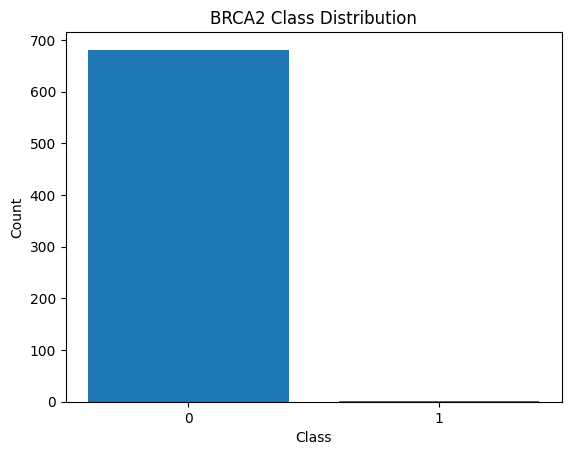

In [ ]:
warnings.filterwarnings('ignore')

for variant_name in variant_names:    
	curr_vus = vus[variant_name]
	curr_classified = classified[variant_name]
	curr_unclassified = unclassified[variant_name]
	curr_leftover = leftover[variant_name]
	
	# if len(curr_classified) < 10:
	#     continue
	
	vus_df = variants_to_dataframe(curr_vus)
	classified_df = variants_to_dataframe(curr_classified)
	unclassified_df = variants_to_dataframe(curr_unclassified)
	leftover_df = variants_to_dataframe(curr_leftover)
	
	def qc(df, cols):
		out = {}
		for c in cols:
			s = df[c]
			out[c] = {
				"n": len(s),
				"nan%": float(s.isna().mean()*100),
				"min": float(s.min()) if s.dropna().size else None,
				"max": float(s.max()) if s.dropna().size else None,
				"uniq<=5": s.dropna().unique()[:5].tolist() if s.dropna().nunique()<=5 else None
			}
		return out

	qc_report = qc(classified_df, [c for c in training_columns if c!='label'])
	print(qc_report)
	
	class_counts = classified_df["label"].value_counts().sort_index()
	
	dir_name = f"others/{variant_name}"
	os.makedirs(f"data/{dir_name}", exist_ok=True)
	
	vus_df.to_csv(f"data/{dir_name}/vus_{variant_name}_{len(curr_vus)}_bio.txt", sep="\t", index=False, na_rep=999)
	classified_df.to_csv(f"data/{dir_name}/classified_{variant_name}_{len(curr_classified)}_bio.txt", sep="\t", index=False, na_rep="999")
	unclassified_df.to_csv(f"data/{dir_name}/unclassified_{variant_name}_{len(curr_unclassified)}_bio.txt", sep="\t", index=False, na_rep=999)
	leftover_df.to_csv(f"data/{dir_name}/leftover_{variant_name}_{len(curr_leftover)}_bio.txt", sep="\t", index=False, na_rep=999)

	print(class_counts)
	
	plt.bar(class_counts.index, class_counts.values)
	plt.xticks([0, 1])
	plt.xlabel("Class")
	plt.ylabel("Count")
	plt.title(f"{variant_name} Class Distribution")
	plt.show()